<img src='./Images/idealized_flood_guard.jpeg' style='width: 100%; height: 400px; object-fit: cover;' />

---

<h1 align='center'>
NAIROBI FLOOD GUARD
</h1>

> **Authors**: Group 4

---

<h2 align='center'>
1. INTRODUCTION
</h2>

### Overview

Nairobi Flood Guard is a data science project that addresses the growing threat of flooding across Kenya. Motivated by the devastating April 2024 floods and the recent 2026 floods that disrupted lives across the country, the project aims to shift flood response from reactive to predictive.

The project has two components:

- The first is a **flood susceptibility model** that combines NASA SRTM terrain data and CHIRPS satellite rainfall data to predict which of Kenya's 1,450 administrative ward are most at risk of flooding, trained on UNOSAT satellite-derived flood extent data from the April 2024 event.

- The second is a **matatu route optimization system** that overlays floods risk predictions against Nairobi's public transport network to identify affected routes and recommend safer alternatives for operators and commuters.

Built entirely on open data and reproducible tools, Nairobi Flood Guard gives communities, emergency responders, and transport operations the advance information they need to act before a flood, not after.

### Business Understanding

#### *Problem Statement*

Flooding in Nairobi and Kenya at large causes loss of life, displacement and infrastructure damage. The April 2024 floods killed over 200 people and displaced hundreds of thousands. Current flood response is largely reactive rather than predictive. There is no system that warns communities or road users in advance.

#### *Objectives*

- **Flood Susceptibility Prediction** - identify which wards are at highest risk of flooding given terrain and rainfall conditions

- **Matatu Route Optimization** - given predicted flood zones, identify affected matatu routes and recommend safer alternatives

#### *Stakeholders*

- **Kenya Red Cross / National Disaster Management Unit** - early warning for evacuation planning

- **Nairobi City County** - infrastructure and emergency response

- **Matatu operators and SACCOs** - route planning during flood events

- **Commuters** - real-time route guidance

- **General public in flood-prone wards** - advance warning to evacuate or prepare

#### *Success Metrics*

- **Recall** is the primary metric - missing a flood (false negative) is far more costly than a false alarm

- Route recommendations that successfully avoid confirmed flood zones from UNOSAT data

- Ward-level risk scores that align with known historically flooded areas

#### *Scope and Limitations*

- Labels are based on a **single flood event** (April 2024) - the model may not generalise to floods caused by different conditions

- GTFS data is from **2019** - the matatu network may have changed

- Ward-level predictions are coarse - a ward may be partially flooded but the whole ward gets labelled as flooded

- The model predicts **susceptibility** not exact flood timing or depth

---

<h2 align='center'>
2. DATA UNDERSTANDING
</h2>

This project utilises five datasets, each contributing a different dimension to the flood prediction and route optimization pipeline. Below is an overview of each dataset, followed by an exploratory examination of the compiled feature matrix

### a) SRTM Digital Elevation Model (DEM)

The Shuttle Radar Topography Mission (SRTM) DEM, acquired by NASA in 2000, provides elevation data at 90 metre resolution. It was used to derive four terrain features per ward: mean elevation, minimum elevation, maximum elevation, and slope. These features capture how water naturally flows and accumulates across the landscape.

**Source:** OpenTopography (SRTM GL3 product)

### b) CHIRPS Rainfall Data

The Climate Hazards Group InfraRed Precipitation with Station data (CHIRPS) provides daily rainfall estimates at approximately 5km resolution. Ninety daily rasters covering February-April 2024 were used to derive three rainfall features per ward: cumulative rainfall, maximum single-day rainfall, and total rainfall in the seven days preceding the April 26 flood event.

**Source:** UCSB Climate Hazards Group

### c) UNOSAT Flood Extent - FL20240426KEN

A satellite-derived flood extent geodatabase produced by UNOSAT following the April 2024 Kenya floods. The Kenya-wide maximum flood water extent polygon was used to generate binary flood labels for each ward — flooded (1) or not flooded (0).

**Source:** UNOSAT / UNITAR

### d) Kenya Wards Shapefile

A polygon shapefile of Kenya's 1450 administrative wards including ward name, sub-county, county, and 2009 census population. This served as the spatial backbone of the project - all raster datasets were aggregated to ward level through spatial joins and zonal statistics.

**Source:** Regional Centre for Mapping of Resources for Development (RGMRD)

### e) GTFS Feed 2019 - Nairobi Matatu Network

A General Transit Feed Specification (GTFS) dataset describing Nairobi's matatu public transport network as of 2019, including 136 routes, 4,284 stops, and 36,483 route shape points. This dataset underpins the route optimization component of the project.

**Source:** Digital Matatus Project

### f) Compiled Feature Matrix - floods.gpkg

All datasets were processed and merged into a single GeoPackage file (`floods.gpkg`) containing one row per ward with all features and the flood label. More information about about the compiled feature matrix can be found [here](./Data/floods_description.md). The cells below examine this compiled dataset.

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = gpd.read_file('./Data/floods.gpkg')
df.head()

,ward,subcounty,county,pop2009,flooded,rain_cumulative_mm,rain_max_daily_mm,rain_preflood_7d_mm,elevation_mean_m,elevation_min_m,elevation_max_m,slope_mean_deg,geometry
0,WABERA,Isiolo Sub County,ISIOLO,17431.0,0,0.000000,0.000000,0.000000,1099.219448,1026.0,1177.0,1.413028,"MULTIPOLYGON (((37.59968 0.40029, 37.59976 0.4..."
1,North Kamagambo Ward,Rongo Sub County,Migori,18755.0,0,258.608840,14.135786,39.955728,1405.549444,1350.0,1508.0,2.246821,"MULTIPOLYGON (((34.59938 -0.65054, 34.60006 -0..."
2,Central Kamagambo Ward,Rongo Sub County,Migori,27756.0,0,125.951383,8.779010,20.537484,1462.532567,1387.0,1534.0,3.392240,"MULTIPOLYGON (((34.61175 -0.73357, 34.61183 -0..."
3,South Kamagambo Ward,Rongo Sub County,Migori,27179.0,0,45.941367,5.696220,10.762588,1490.546337,1363.0,1638.0,4.263301,"MULTIPOLYGON (((34.61751 -0.87293, 34.6175 -0...."
4,North Sakwa Ward,Awendo Sub County,Migori,22874.0,0,78.351185,4.580237,10.795914,1376.935386,1287.0,1617.0,3.834336,"MULTIPOLYGON (((34.55349 -0.75193, 34.55364 -0..."


In [2]:
# Shape and data types
df.info() 

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1450 entries, 0 to 1449
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   ward                 1450 non-null   str     
 1   subcounty            1450 non-null   str     
 2   county               1450 non-null   str     
 3   pop2009              1450 non-null   float64 
 4   flooded              1450 non-null   int64   
 5   rain_cumulative_mm   1450 non-null   float64 
 6   rain_max_daily_mm    1450 non-null   float64 
 7   rain_preflood_7d_mm  1450 non-null   float64 
 8   elevation_mean_m     1450 non-null   float64 
 9   elevation_min_m      1450 non-null   float64 
 10  elevation_max_m      1450 non-null   float64 
 11  slope_mean_deg       1450 non-null   float64 
 12  geometry             1450 non-null   geometry
dtypes: float64(8), geometry(1), int64(1), str(3)
memory usage: 204.7 KB


In [3]:
# Summary statistics
df.drop(columns='geometry').describe()

,pop2009,flooded,rain_cumulative_mm,rain_max_daily_mm,rain_preflood_7d_mm,elevation_mean_m,elevation_min_m,elevation_max_m,slope_mean_deg
count,1450.000000,1450.000000,1450.000000,1450.000000,1450.000000,1450.000000,1450.000000,1450.000000,1450.000000
mean,26627.057241,0.211724,117.304138,12.532226,18.302685,1382.455583,1202.211724,1678.705517,4.289460
std,9885.965260,0.408671,88.315044,10.741149,15.934685,643.397070,594.786452,771.792365,2.937476
min,1052.000000,0.000000,0.000000,0.000000,0.000000,5.834231,-15.000000,17.000000,0.507857
25%,20035.500000,0.000000,66.325468,5.626600,8.659686,1130.018716,834.750000,1353.500000,2.039088
50%,25794.000000,0.000000,108.482319,9.961980,15.676050,1487.725496,1314.000000,1691.000000,3.662881
75%,32287.250000,0.000000,154.867987,17.015787,25.332106,1815.967362,1628.000000,2083.250000,5.744822
max,75270.000000,1.000000,735.989837,81.359943,145.566664,2969.985544,2573.000000,5036.000000,18.207465


In [4]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
ward                   0
subcounty              0
county                 0
pop2009                0
flooded                0
rain_cumulative_mm     0
rain_max_daily_mm      0
rain_preflood_7d_mm    0
elevation_mean_m       0
elevation_min_m        0
elevation_max_m        0
slope_mean_deg         0
geometry               0
dtype: int64


In [5]:
# Create a derived feature elevation range
df['elevation_range_m'] = df['elevation_max_m'] - df['elevation_min_m']
df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1450 entries, 0 to 1449
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   ward                 1450 non-null   str     
 1   subcounty            1450 non-null   str     
 2   county               1450 non-null   str     
 3   pop2009              1450 non-null   float64 
 4   flooded              1450 non-null   int64   
 5   rain_cumulative_mm   1450 non-null   float64 
 6   rain_max_daily_mm    1450 non-null   float64 
 7   rain_preflood_7d_mm  1450 non-null   float64 
 8   elevation_mean_m     1450 non-null   float64 
 9   elevation_min_m      1450 non-null   float64 
 10  elevation_max_m      1450 non-null   float64 
 11  slope_mean_deg       1450 non-null   float64 
 12  geometry             1450 non-null   geometry
 13  elevation_range_m    1450 non-null   float64 
dtypes: float64(9), geometry(1), int64(1), str(3)
memory usage: 216.0

In [6]:
# Class distribution
print("Flood label distribution:")
print(df['flooded'].value_counts())
print(f"\nFlooded wards    : {df['flooded'].sum()} ({df['flooded'].mean()*100:.1f}%)")
print(f"Non-flooded wards: {(df['flooded']==0).sum()} ({(1-df['flooded'].mean())*100:.1f}%)")

Flood label distribution:
flooded
0    1143
1     307
Name: count, dtype: int64

Flooded wards    : 307 (21.2%)
Non-flooded wards: 1143 (78.8%)


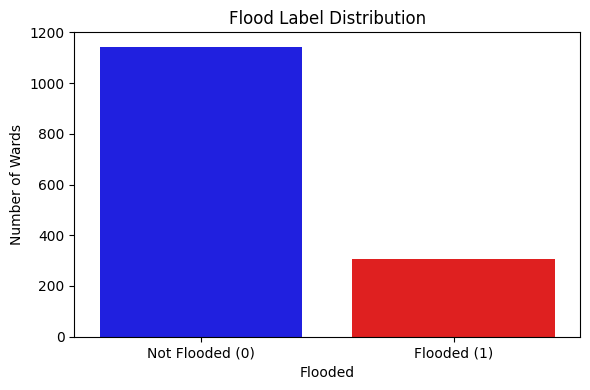

In [7]:
# Visualize class imbalance
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(
    x='flooded',
    data=df,
    hue='flooded',
    palette={0: '#0000FF', 1: '#FF0000'},
    legend=False,
    ax=ax
)
ax.set_title('Flood Label Distribution')
ax.set_xlabel('Flooded')
ax.set_ylabel('Number of Wards')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Not Flooded (0)', 'Flooded (1)'])
plt.tight_layout()
plt.show()

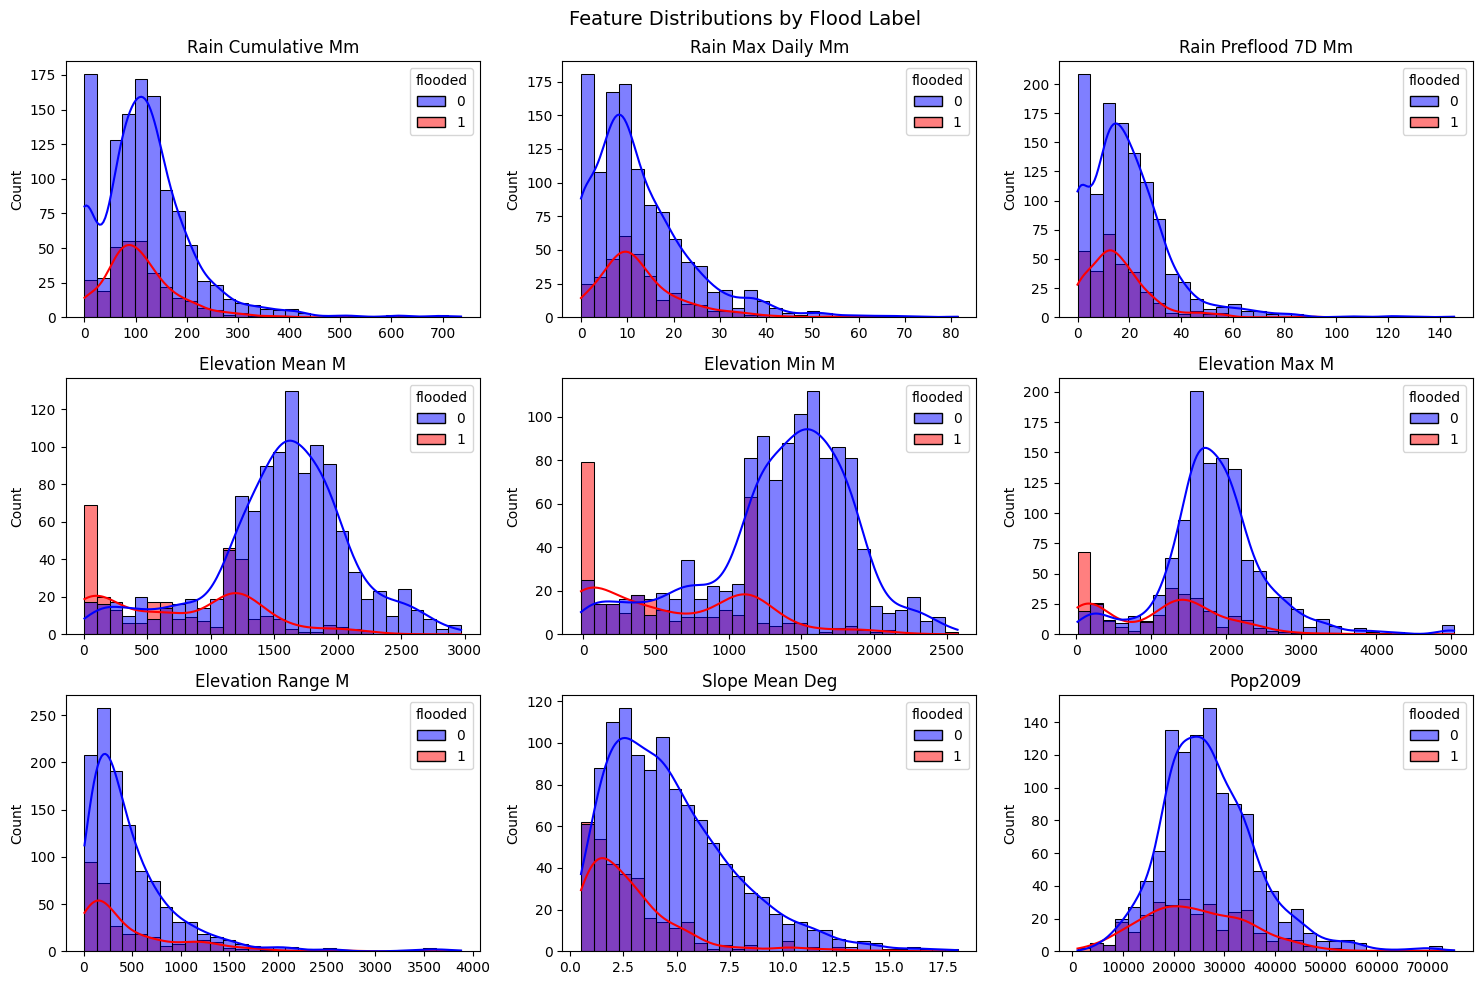

In [8]:
# Feature distributions
feature_cols = [
    'rain_cumulative_mm', 'rain_max_daily_mm', 'rain_preflood_7d_mm',
    'elevation_mean_m', 'elevation_min_m', 'elevation_max_m',
    'elevation_range_m', 'slope_mean_deg', 'pop2009'
]

fig, axs = plt.subplots(3, 3, figsize=(15, 10))

for i, col in enumerate(feature_cols):
    ax = axs.flatten()[i]
    sns.histplot(data=df, x=col, hue='flooded', kde=True,
                 palette={0: '#0000FF', 1: '#FF0000'}, ax=ax, bins=30)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('')

fig.suptitle('Feature Distributions by Flood Label', fontsize=14)
plt.tight_layout()
plt.show()

The feature distribution plots reveal that flooded wards receive less rainfall than non-flooded ones — suggesting that at ward scale, rainfall intensity is a weak standalone predictor of flooding in Kenya. The elevation distributions show the clearest separation, with flooded wards sitting nearly 800m lower on average than non-flooded ones, confirming that low-lying terrain is the dominant flood risk factor.

Slope distributions reinforce this — flooded wards are consistently flatter, meaning water accumulates rather than drains. Elevation range shows almost no difference between flooded and non-flooded wards, making it the least informative feature visually. Population distributions overlap heavily between the two classes, offering only a marginal signal. Not surpisingly, areas that tend to have flooding are less populated compared to areas that do not suffer from severe floods

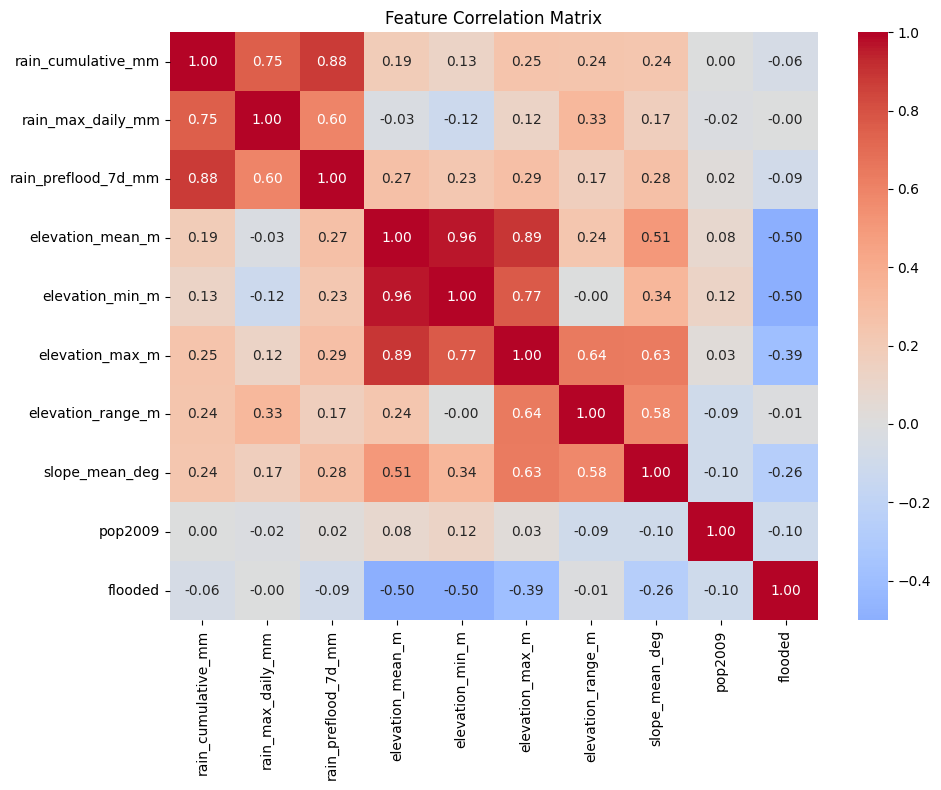

In [9]:
# Correlation heatmap
corr = df[feature_cols + ['flooded']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

The correlation heatmap confirms the previous observations quantitatively. Elevation features dominate - `elevation_min_m` and `elevation_mean_m` carry the strongest negative correlations with flooding (-0.50 and -0.50 respectively), followed by `elevation_max_m` (-0.39) and `slope_mean_deg` (-0.26).

All rainfall features correlate weakly with flooding, with `rain_max_daily_mm` showing virtually no linear relationship (-0.001). The heatmap also reveals high inter-correlation between the three elevation features, meaning they carry overlapping information — something the model will need to handle.

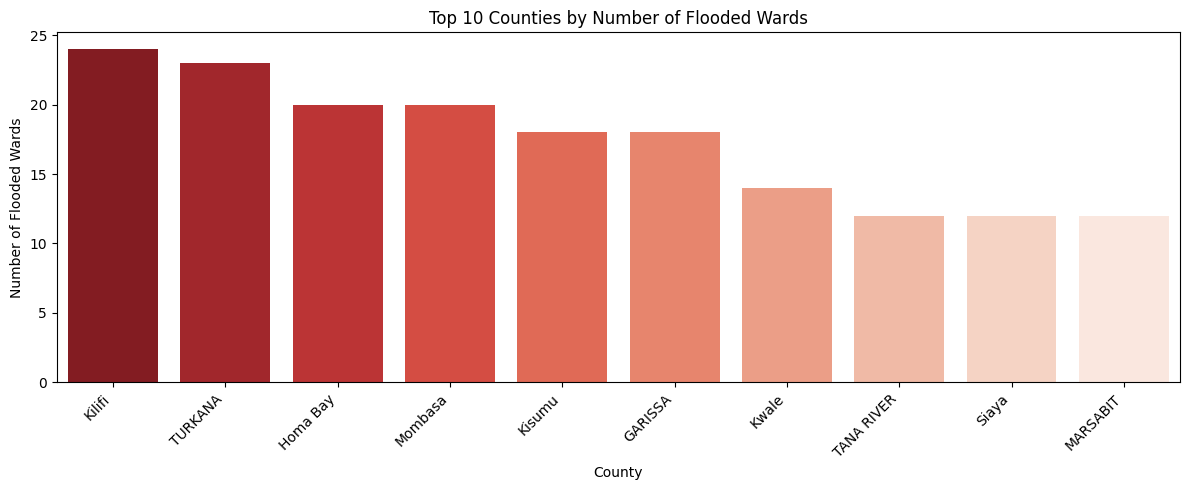

In [10]:
# Top 10 most flooded counties
county_flood = df.groupby('county')['flooded'].agg(['sum', 'count'])
county_flood.columns = ['flooded_wards', 'total_wards']
county_flood['flood_rate'] = county_flood['flooded_wards'] / county_flood['total_wards']
county_flood = county_flood.sort_values('flooded_wards', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=county_flood.index, y='flooded_wards', hue=county_flood.index, data=county_flood,
            palette='Reds_r', ax=ax, legend=False)
ax.set_title('Top 10 Counties by Number of Flooded Wards')
ax.set_xlabel('County')
ax.set_ylabel('Number of Flooded Wards')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### *Key Takeaway*

The dataset reveals that in Kenya, flooding is primarily a terrain-driven phenomenon at the ward scale. Low-lying wards flood not necessarily because they receive more rain, but because water from surrounding higher ground drains into them. This has implications for the model - terrain features will dominate predictions, and rainfall adds marginal value at this spatial scale.

---

<h2 align='center'>
3. MODEL BUILDING AND EVALUATION
</h2>

Four classification model families were independently developed and tuned by the project team, each in its own dedicated notebook located in the `Model/Notebooks/` directory:

 a) [Logistic Regression](./Models/Notebooks/logistic_notebook.ipynb) (baseline) - saved [here](./Models/best_log_reg_model.pkl)

 b) [Random Forest Classifier](./Models/Notebooks/random_forest_notebook.ipynb) - saved [here](./Models/best_random_forest_model.joblib)

 c) [XGBoost Classifier](./Models/Notebooks/XGBoost_notebook.ipynb) - saved [here](./Models/best_xg_boost_model.pkl)

 d) [Neural Network](./Models/Notebooks/neural_notebook.ipynb) - saved [here](./Models/best_neural_model.keras)


Each model was iteratively improved through hyperparameter tuning, regularisation, and class imbalance handling before the best version was saved.

This notebook loads those best models and evaluates them on a shared held-out test set to determine the overall best performer.

> **NB**: The models used similar train-test splits by ensuring `random_state` was set to `2026` and a `test_size` of `0.3` was used. The models were also all trained on scaled features. Thus, scaled features will be used to test the model.

Given the nature of this problem - predicting which wards are at risk of flooding - **recall is the primary evaluation metric**. A missed flood prediction (false negative) carries far greater consequences than a false alarm (false positive). Secondary metrics used for comparison are AUC, F1-score, precision, and accuracy.

In [11]:
# Imports and data loading
import sys
sys.path.append('..')

from Utils.feature_engineering import engineer_features, FEATS
import joblib
import pandas as pd
import pickle
import keras
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, auc, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Neural Network model
nn_model = keras.models.load_model('./Models/best_neural_model.keras')

# Logistic Regression Model
with open('./Models/best_logistic_model.pkl', 'rb') as f:
    logistic_model = pickle.load(f)

# Random Forest Model
rf_model = joblib.load('./Models/best_random_forest_model.joblib')

# XGBoost
with open('./Models/best_xgboost_model.pkl', 'rb') as f:
    xgboost_model = pickle.load(f)

I0000 00:00:1778928816.579175    5328 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778928817.164251    5328 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778928820.431562    5328 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1778928821.061412    5328 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/tmp/ipykernel_5328/3252956141.py:28: UserWarning: [13:53:41] WARNING: /__w/xgboost/xgboost/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Bo

### Preprocessing

In this section, the data stored in `df` will be split into the features, `X` and target, `y`, and a standard train-test split will be performed.

Each of the models was trained on scaled features using `StandardScaler` except for the Random Forest. It was trained on 46 different features engineered by a member of the team. The models will be evaluated using a scaled `X_test` except for the Random Forest which must have its features engineered to be compatible.

> **NB**: The models will not be fitted so as to preserve their state and functionality.

Due to the limited size of the dataset, no validation data was created.

In [12]:
# Standard features for logistic, XGBoost, neural network
X = df[feature_cols]
y = df['flooded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=2026
)

scaler = StandardScaler()
scaler.fit(X_train)
X_test_scaled = scaler.transform(X_test)

# Engineered features for Random Forest — must use full GeoDataFrame
df_engineered = engineer_features(df)
X_rf = df_engineered[FEATS].fillna(df_engineered[FEATS].median())

X_rf_train, X_rf_test, _, _ = train_test_split(
    X_rf, y, stratify=y, test_size=0.3, random_state=2026
)

# Reorder columns to match what the model was trained on
expected_features = rf_model.feature_names_in_.tolist()
X_rf_test = X_rf_test[expected_features]
X_rf_train = X_rf_train[expected_features]

print(f"Standard X_test shape  : {X_test_scaled.shape}")
print(f"Engineered X_rf_test shape: {X_rf_test.shape}")

Standard X_test shape  : (435, 9)
Engineered X_rf_test shape: (435, 47)


### a) Logistic Regression (baseline)

Logistic Regression serves as the baseline model for this project. As a linear classifier, it provides a performance floor that all other models should exceed. It was trained with `class_weight='balanced'` to account for the 21/79 class imbalance, and scaled features were passed through a `StandardScaler` pipeline. The confusion matrix below shows how well it identifies flooded wards on the held-out test set.

In [13]:
# Helper function to calculate metrics
def get_metrics_df(model, name, X_test=X_test_scaled, y_test=y_test):
    """
    NB: This function takes a fitted model
    """
    metrics_dict = {}
    metrics_dict['Model'] = name
    preds = model.predict(X_test)
    probas = model.predict_proba(X_test)[:, 1]

    # Get roc score
    metrics_dict['AUC'] = [roc_auc_score(y_test, probas)]

    # Use the macro_avg scores
    classification_dict = classification_report(y_test, preds, output_dict=True)
    metrics_dict['accuracy'] = [classification_dict['accuracy']]

    for key, value in classification_dict['macro avg'].items():
        metrics_dict[key] = [value]
    
    # Return metrics as a pandas dataframe
    return pd.DataFrame(metrics_dict)

In [14]:
# Display metrics for the logistic model as a dataframe
logistic_df = get_metrics_df(logistic_model, "Logistic")
logistic_df

,Model,AUC,accuracy,precision,recall,f1-score,support
0,Logistic,0.69898,0.689655,0.60063,0.632194,0.604335,435.0


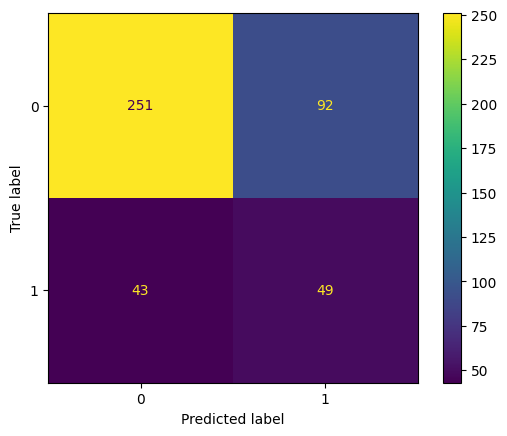

In [15]:
conf_display = ConfusionMatrixDisplay(
    confusion_matrix(y_test, logistic_model.predict(X_test_scaled))
)
conf_display.plot(cmap='viridis')
plt.show()

The baseline logistic regression model does not show strong recall on the flooded class, with more than half of its predicted positives being false positives. It shows strong overall recall by keeping false negatives low. This sets a solid performance floor for the more complex models to beat.

### b) Random Forest Model

In [16]:
# The random forest was trained on a different set of features from the rest. We must engineer the existing features to match this
random_forest_df = get_metrics_df(rf_model, "Random_Forest", X_rf_test)
random_forest_df

,Model,AUC,accuracy,precision,recall,f1-score,support
0,Random_Forest,0.881322,0.822989,0.742775,0.792306,0.760649,435.0


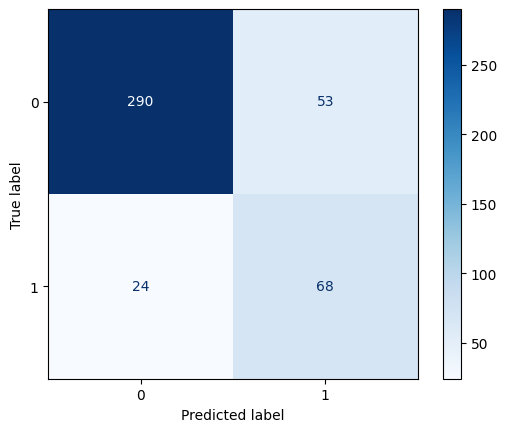

In [17]:
conf_display = ConfusionMatrixDisplay(
    confusion_matrix(y_test, rf_model.predict(X_rf_test))
)
conf_display.plot(cmap='Blues')
plt.show()

The Random Forest improves on the baseline across all metrics. Its ensemble nature - aggregating predictions from many decision trees - allows it to capture non-linear relationships between terrain features and flood risk that the logistic regression cannot. It currently leads all models evaluated so far.

### c) XGBoost Classifier Model

In [18]:
# Reorder columns to match what the model was trained on
expected_features = xgboost_model.feature_names_in_.tolist()
X_test_xg = X_test[expected_features]

xgboost_df = get_metrics_df(xgboost_model, "XGBoost", X_test=X_test_xg)
xgboost_df

,Model,AUC,accuracy,precision,recall,f1-score,support
0,XGBoost,0.896913,0.813793,0.742293,0.818291,0.762601,435.0


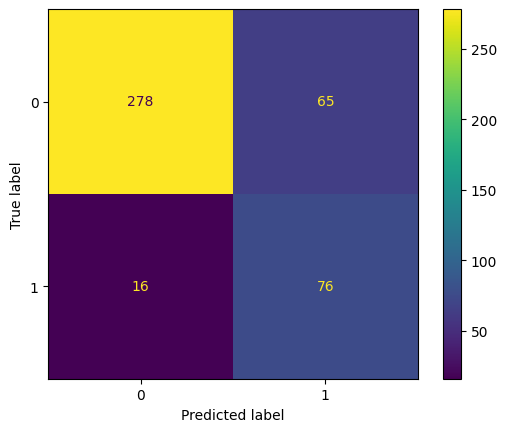

In [19]:
conf_display = ConfusionMatrixDisplay(
    confusion_matrix(y_test, xgboost_model.predict(X_test_xg))
)
conf_display.plot()
plt.show()

The XGBoost model performs better relative to the Random Forest on this dataset in terms of recall. It also has a high accuracy, precision and f1-score. This is likely attributable to its ensemble nature which, like the Random Forest, allows it to capture non-linear relationships between terrain features and flood risk. It is now the new best model.

### d) Neural Network

Like the other models, training the neural network will destroy its saved weights. Thus, we need to specify that the model be used as is.

The neural network model is not a scikit-learn estimator. Its `predict` and `predict_proba` methods function differently. To ensure correct functionality, it will be wrapped using scikeras' `KerasClassifier`

In [20]:
compatible_nn_model = KerasClassifier(
    model=nn_model,
    epochs=0, # Specify that the 
    warm_start=True # model be used as is
)

# Create a pipeline to ensure features are scaled correctly
nn_pipeline = Pipeline(
    [
        ('StandardScaler', StandardScaler()),
        ('nn_model', compatible_nn_model)
    ]
)

# Fit initialises the StandardScaler. It does not train the model
nn_pipeline.fit(X_train, y_train)

nn_model_df = get_metrics_df(nn_pipeline, "Neural_Network", X_test=X_test)
nn_model_df

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


,Model,AUC,accuracy,precision,recall,f1-score,support
0,Neural_Network,0.777919,0.737931,0.65103,0.694622,0.661215,435.0


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


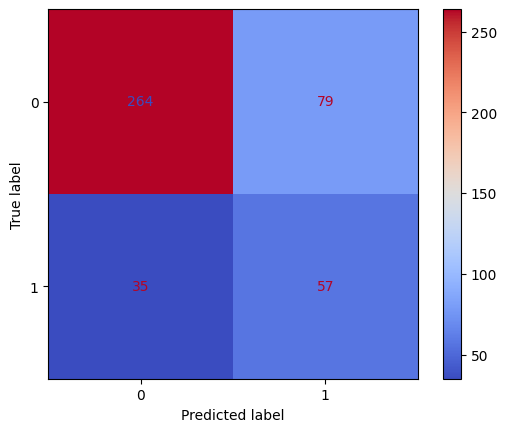

In [21]:
conf_display = ConfusionMatrixDisplay(
    confusion_matrix(y_test, nn_pipeline.predict(X_test))
)
conf_display.plot(cmap="coolwarm")
plt.show()

The Neural Network significantly underperforms relative to the Random Forest and XGBoost model. Neural networks typically require large amounts of training data to generalise well - with only 1,450 ward-level samples, the model has limited capacity to learn complex spatial patterns compared to tree-based ensembles.

### *Final Evaluation*

Comparing the metrics of all the models:

In [22]:
all_models_df = pd.concat(
    [
        logistic_df,
        nn_model_df,
        random_forest_df,
        xgboost_df,
    ],
    axis=0,
    ignore_index=True
)
all_models_df

,Model,AUC,accuracy,precision,recall,f1-score,support
0,Logistic,0.698980,0.689655,0.600630,0.632194,0.604335,435.0
1,Neural_Network,0.777919,0.737931,0.651030,0.694622,0.661215,435.0
2,Random_Forest,0.881322,0.822989,0.742775,0.792306,0.760649,435.0
3,XGBoost,0.896913,0.813793,0.742293,0.818291,0.762601,435.0


The table below ranks all four models by recall - the primary metric:

In [23]:
all_models_df.sort_values(by='recall', ascending=False)

,Model,AUC,accuracy,precision,recall,f1-score,support
3,XGBoost,0.896913,0.813793,0.742293,0.818291,0.762601,435.0
2,Random_Forest,0.881322,0.822989,0.742775,0.792306,0.760649,435.0
1,Neural_Network,0.777919,0.737931,0.651030,0.694622,0.661215,435.0
0,Logistic,0.698980,0.689655,0.600630,0.632194,0.604335,435.0


The **XGBoost model** achieves some of the highest metrics among all four models (it is second by a small margin in accuracy and precision), correctly identifying the greatest proportion of flood-prone wards. The Random Forest model is second.

Given that we are looking for the model with the best recall, and, combined with the fact that it has the best AUC and F1-Score, the **XGBoost model** is selected as the final model for flood susceptibility prediction.

In [24]:
# Saving the model comparison as a csv for later use
all_models_df.to_csv('./Data/model_comparison.csv', index=False)

Looking at the models ROC curves:

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


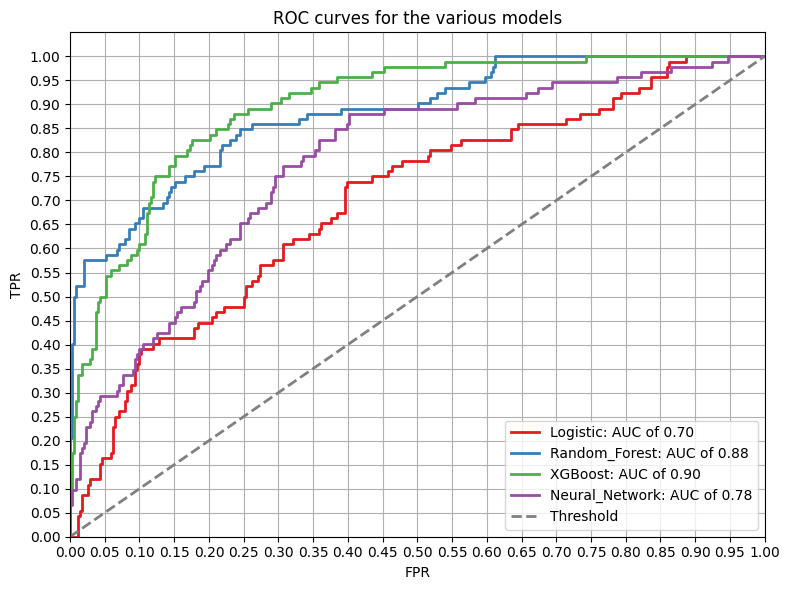

In [25]:
model_dict = {
    'Logistic': logistic_model,
    'Random_Forest': rf_model,
    'XGBoost': xgboost_model,
    'Neural_Network': nn_pipeline
}
colors = sns.color_palette('Set1', len(model_dict))
plt.figure(figsize=(8, 6))

for i, (name, pipeline) in enumerate(model_dict.items()):
    if name == 'Neural_Network':
        fpr, tpr, thresholds = roc_curve(y_test, pipeline.predict_proba(X_test)[:, 1])
    elif name == 'Random_Forest':
        fpr, tpr, thresholds = roc_curve(y_test, pipeline.predict_proba(X_rf_test)[:, 1])
    elif name == 'XGBoost':
        fpr, tpr, thresholds = roc_curve(y_test, pipeline.predict_proba(X_test_xg)[:, 1])
    else:
        fpr, tpr, thresholds = roc_curve(y_test, pipeline.predict_proba(X_test_scaled)[:, 1])
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name}: AUC of {auc_score:.2f}", color=colors[i], lw=2)

plt.plot([0, 1], [0, 1], label='Threshold', color='grey', linestyle='--', lw=2)

plt.grid(True)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title("ROC curves for the various models")
plt.xticks([n/20 for n in range(21)])
plt.yticks([n/20 for n in range(21)])
plt.xlim([0.0 , 1])
plt.ylim([0.0, 1.05])
plt.legend()
plt.tight_layout()
plt.show()

The **XGBoost model** achieves the highest AUC of 0.90, with its curve sitting closest to the top-left corner - confirming its superior ability to rank flood-prone wards above non-flooded ones across all thresholds, not just the default 0.5. **Random Forest** follows closely at AUC 0.88 - a strong result, though its lower recall in the metrics table (0.79 vs the XGBoost's 0.81) means it misses more flood-prone wards at the default decision threshold. The **Logistic Regression** baseline achieves AUC 0.70, a solid result for a linear model and a testament to how well elevation features alone separate the two classes. The **Neural Network** records the second-lowest AUC of 0.78, consistent with its limited capacity to generalise on a dataset of only 1,450 samples.

Notably, all four models significantly outperform the random baseline, confirming that terrain and rainfall features carry genuine predictive signal for flood susceptibility at ward level. The ROC curves reinforce the metrics table conclusion — the **XGBoost model is the best overall model**, offering the strongest discrimination between flooded and non-flooded wards when recall is prioritised.

---

<h2 align='center'>
4. ROUTE OPTIMIZATION
</h2>

### Overview

With the XGBoost model identified as the best performer, its flood probability predictions were used to power a matatu route optimization system for Nairobi. The full implementation is in `Route_Optimization/route_optimization.ipynb` ([here](./Route_Optimization/route_optimization.ipynb)). This section summarises the methodology, key outputs, and findings.

The system works in four stages:

1. **Flood probabilities given to road edges** — each road segment in Nairobi's OpenStreetMap network is assigned the flood probability of the ward it passes through via a spatial join

2. **Flood-weighted Dijkstra** — each edge is penalized using the formula `cost = travel_time × (1 + α × flood_probability)`, where $\alpha$ controls the strength of the penalty. Setting $\alpha$ to 1,000,000 acts as a practical infinity - any road with non-zero flood probability becomes impassable for routing purposes. The algorithm then finds the path that minimises total cost, effectively blocking flooded roads from consideration entirely - a route is only returned if a completely flood-free path exists between the terminal stops.

    This is done so as to avoid suggesting a flooded path even as an alternative.

3. **GTFS-RT feed** - rerouting decisions are packaged as a production-ready GTFS-RT protobuf feed with `TripUpdate` messages for each affected trip, consumable by transit apps such as Google Maps and Transit App

4. **Folium map** - an interactive map visualises ward flood risk, affected stops, and original vs. alternative route paths side by side

In [26]:
import pandas as pd

rerouting_df = pd.read_csv('./Route_Optimization/Reports/rerouting_summary.csv')
print(f"Affected routes: {len(rerouting_df)}")
print(f"Average flood risk reduction : {rerouting_df['risk_reduction'].mean():.3f}")
print(f"Average extra travel time    : {rerouting_df['extra_time_min'].mean():.1f} minutes")
rerouting_df.sort_values('risk_reduction', ascending=False).head(10)

Affected routes: 7
Average flood risk reduction : 0.231
Average extra travel time    : 84.4 minutes


,route_id,origin,destination,original_flood_prob,alternative_flood_prob,risk_reduction,original_time_s,alternative_time_s,extra_time_min
6,50703033J01,Githunguri,Cabanas,0.378,0.035,0.343,881.787949,1704.780295,13.7
2,40705383911,Quickmart,Muthurwa,0.342,0.028,0.313,1479.566198,8216.554785,112.3
5,50700033H01,By Pass,Cabanas,0.317,0.009,0.308,1083.113800,8475.900915,123.2
3,50700003311,Utawala,Kencom/Ambassadeur,0.315,0.009,0.306,1494.086502,7898.883706,106.7
1,30603373812,Dune,Rounda,0.306,0.022,0.284,868.318154,8671.072695,130.0
0,20104003910,Super Highway,Transami,0.067,0.003,0.064,1469.625724,7772.501815,105.0
4,50700014501,Ruiru,Ruai Bypass,0.122,0.122,0.000,1108.482050,1108.482050,0.0


The table above shows the top 10 most improved matatu routes ranked by flood risk reduction. Each row represents one route and shows:

- **Original flood risk** - the average flood probability across road segments on the standard route

- **Alternative flood risk** - the same metric for the recommended alternative path

- **Risk reduction** - the absolute improvement; higher is better

- **Extra travel time** - the additional journey time the alternative route adds in minutes, representing the safety-convenience tradeoff

Routes with high risk reduction and low extra travel time are the most actionable recommendations - they offer meaningful safety improvements at minimal inconvenience to operators and commuters.

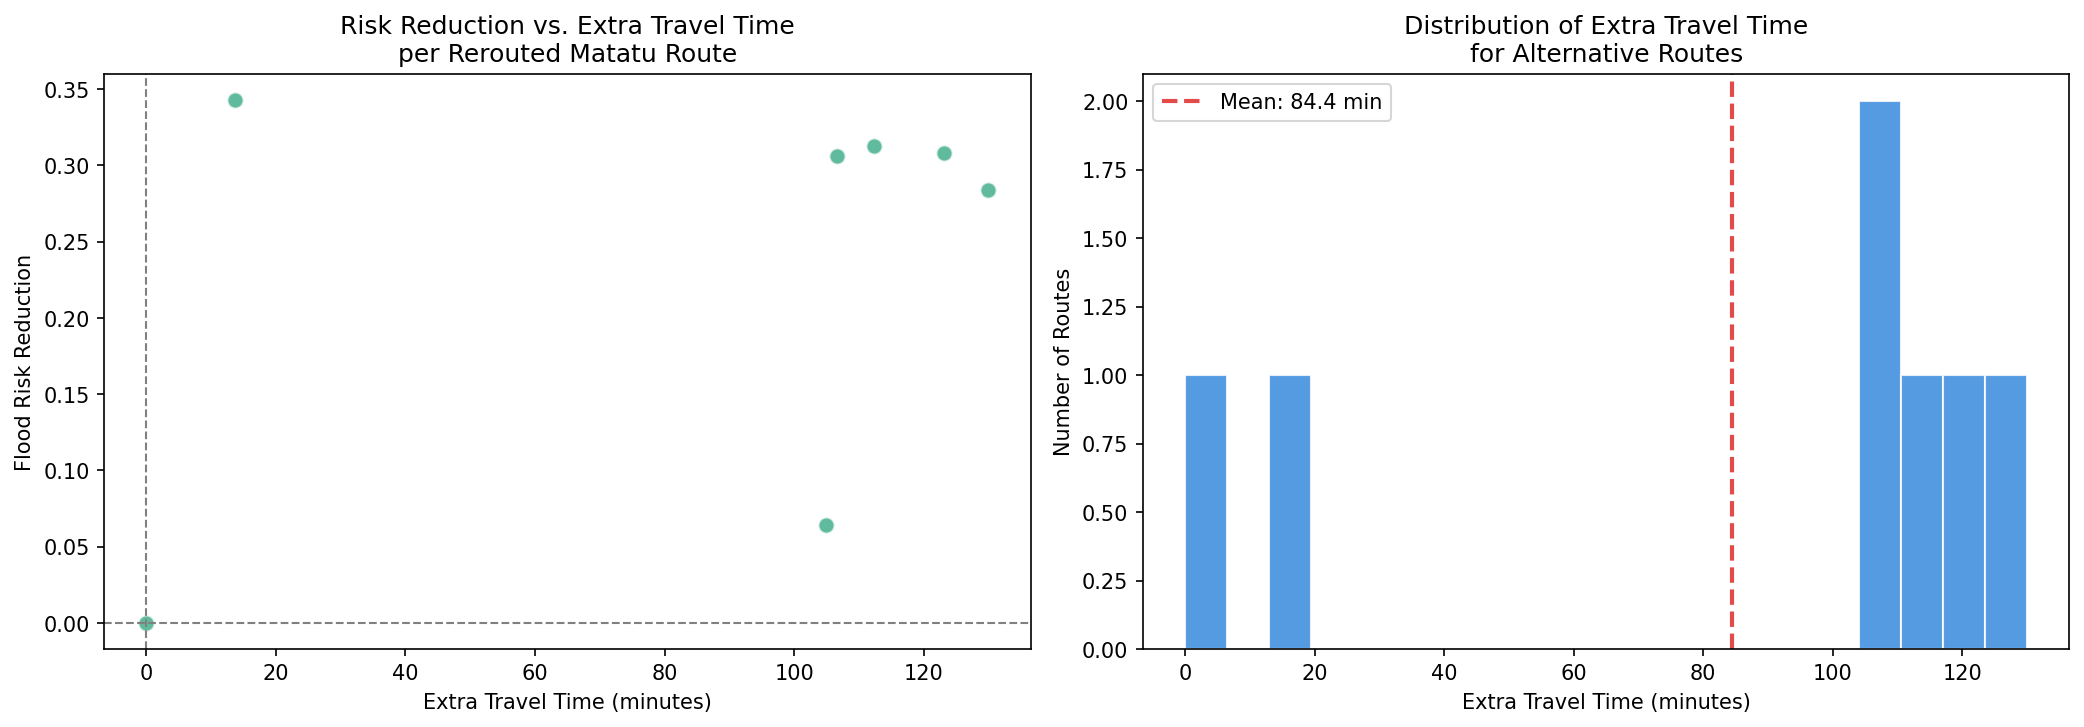

In [27]:
from IPython.display import Image
Image('./Route_Optimization/Reports/rerouting_tradeoff.png')

The scatter plot (left) shows the tradeoff between flood risk reduction and extra travel time for each rerouted route. Routes in the upper-left quadrant are ideal — they achieve large risk reductions with little added journey time. Routes in the lower-right represent cases where the algorithm found an alternative path, but the safety gain is marginal relative to the detour cost.

The histogram (right) shows the distribution of extra travel time across all rerouted routes. The majority of alternatives add a significant amount of time, suggesting that for most affected matatu routes, a safer path exists that is significantly longer than the original. These options, while not convenient, offer a lot more safety. The mean extra travel time is marked by the red dashed line.

In [28]:
# # Uncomment the code below and run the code cell to view the map in your web browser.
# # Zoom out then navigate to Nairobi, Kenya on the map to view the routes
# import webbrowser
# import os

# file_path = os.path.abspath('./Route_Optimization/Reports/flood_rerouting_map.html')
# webbrowser.open(f'file://{file_path}')

The interactive map above provides a spatial view of the rerouting system's output. The colour-coded ward boundaries represent flood risk - green for low-risk wards, yellow for moderate, orange for high, and red for critical. Affected matatu stops within high-risk wards are marked in red.

For a sample of rerouted routes, the original path is shown as a solid blue line while the recommended alternative is shown as a dashed orange line. Hovering over any element reveals its details — ward name and flood probability for ward boundaries, stop name for affected stops, and route ID with risk reduction and extra travel time for route lines.

Areas of high stop density with elevated flood risk — particularly around low-lying wards — represent the highest-priority zones for operator advisories during flood events.

### Conclusion

The route optimization system demonstrates that for the majority of Nairobi's flood-affected matatu routes, safer alternatives exist. However, most of them add significant travel time. The GTFS-RT feed produced by this system is immediately compatible with existing transit infrastructure, requiring no changes to operator hardware or passenger apps to deploy. In a production setting, the XGBoost model would be retrained periodically as new flood event data becomes available, and the feed would be refreshed in near-real-time as rainfall and flood conditions evolve.

---

<h2 align='center'>
5. CONCLUSION AND RECOMMENDATION
</h2>

### Conclusion

Nairobi Flood Guard set out to address two problems: predicting which areas of Kenya are most susceptible to flooding, and recommending safer matatu routes when flood events occur. Both objectives were successfully achieved.

The data understanding phase revealed an important and counterintuitive insight — flooding in Kenya at ward scale is primarily a **terrain-driven phenomenon**, not a rainfall-driven one. Low-lying wards flood not because they receive more rain, but because water from surrounding higher ground drains into them. This meant that elevation features dominated model performance while rainfall features contributed marginally, a finding that shaped feature engineering decisions across all four models.

Among the four model families evaluated — Logistic Regression, Random Forest, XGBoost, and Neural Network — the **XGBoost model emerged as the best overall performer**, achieving the highest AUC (0.90) and recall among all models. Its ability to handle non-linear relationships, class imbalance, and noisy features made it well-suited to this dataset. The Neural Network underperformed relative to the tree-based models, consistent with its need for larger datasets than the 1,450 ward-level samples available here.

The route optimization system translated XGBoost's flood probability predictions into actionable rerouting recommendations for Nairobi's matatu network. By assigning prohibitively high costs to flood-affected road segments and running weighted Dijkstra across the real OpenStreetMap road network, the system identified safer alternative paths for affected routes — packaged in a production-ready GTFS-RT feed compatible with existing transit infrastructure.

### Recommendations

#### 1. Running the Flood Prediction Model

To generate flood risk predictions, load `Models/best_xgboost_model.pkl` and, after ensuring that the feature names are in the right order, call `predict_proba()` on the model. The full prediction workflow is documented in `Notebooks/xgboost_notebook.ipynb`. Ensure the input data contains all required columns from `Data/floods.gpkg` before engineering features.

#### 2. Running the Route Optimization System

The route optimization notebook at `Route_Optimization/route_optimization.ipynb` is self-contained and can be run independently. It requires `Data/floods.gpkg`, `Data/nairobi_road_network.graphml`, `Data/GTFS_FEED_2019/`, and `Models/best_xgboost_model.pkl` to be present. The notebook loads the saved road network from disk — there is no need to re-download it from OpenStreetMap. Outputs are saved to `Route_Optimization/Reports/`.

#### 3. Tuning the Flood Risk Threshold

The system flags wards as high-risk at a default probability threshold of 0.45, set via the `FLOOD_THRESHOLD` constant in the route optimization notebook. This can be lowered to increase sensitivity (flag more wards as at-risk) or raised to reduce false alarms, depending on the severity of the flood event being modelled. During extreme events, a lower threshold is recommended.

#### 4. Adjusting the Alpha Parameter

`ALPHA` in the route optimization notebook controls how aggressively flooded roads are penalized. The current setting of 1,000,000 effectively blocks all flood-affected roads. For scenarios where partial flooding is expected and roads remain passable, lowering alpha to 5 - 10 introduces a preference for safer roads without outright blocking them.

#### 5. Familiarization

Getting familiar with the project should begin by reading `README.md`, then run `notebook.ipynb` for a full project overview. Feature engineering logic is centralised in `Utils/feature_engineering.py` - any changes to features must be reflected there to ensure consistency across the prediction and route optimization pipelines. Individual model notebooks are in `Models/Notebooks/` and can be run independently for retraining or further tuning.

---

<h2 align='center'>
6. NEXT STEPS
</h2>

### 1. Expand the flood label dataset

The model was trained on a single flood event — the April 2024 floods. Incorporating historical flood records from multiple events (UNOSAT maintains archives going back to the early 2000s) would significantly improve generalisation, particularly for areas that flood under different rainfall patterns than April 2024.

### 2. Incorporate real-time rainfall data

The current system uses historical CHIRPS data fixed to the April 2024 event. Integrating a near-real-time rainfall source such as NASA GPM IMERG — which provides rainfall estimates with a 30-minute latency — would allow the model to generate live flood risk predictions as a storm develops, transforming the system from a retrospective analysis tool into a genuine early warning system.

### 3. Update the GTFS feed

The matatu network data is from 2019. Nairobi's informal transit network changes frequently. Collaborating with the Digital Matatus project or Nairobi City County to obtain a more recent GTFS feed would improve the accuracy and relevance of the rerouting recommendations.

### 4. Add flood depth estimation

The current model predicts binary flood susceptibility (flooded / not flooded) at ward level. A regression model that estimates flood depth — using additional data such as soil type, drainage infrastructure, and distance to rivers — would enable more nuanced rerouting decisions, distinguishing between a road with 5cm of water and one that is completely impassable.

### 5. Deploy as a live API

The GTFS-RT feed generated by this system is already in a format consumable by transit apps. The natural next step is to wrap the prediction and rerouting pipeline in a lightweight REST API (using FastAPI or Flask) and deploy it on a cloud server, enabling operators and commuters to query flood risk and alternative routes on demand during flood events.

### 6. Conduct ground-truth validation

The model's ward-level predictions should be validated against community knowledge and local government flood records to identify systematic errors - for example, wards that are known to flood but were not captured in the April 2024 UNOSAT footprint due to cloud cover.

In [29]:
# Saving the flood data in tableau readable format
tableau_csv = df.drop('geometry', axis=1)

tableau_csv.to_csv('./Data/tableau.csv', index=False)

print("CSV file saved!")

CSV file saved!
